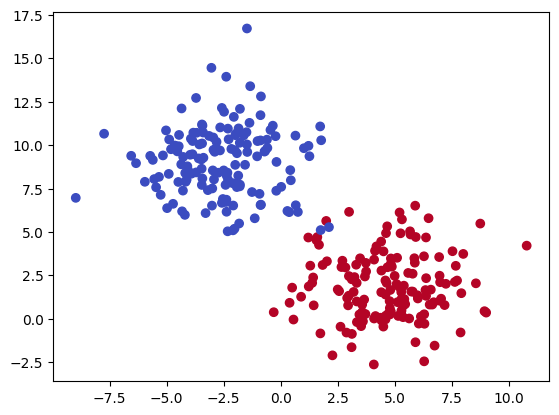

In [1]:
# Lab 1.2 — “Perceptron → Activations → Backprop (from scratch)”
#1 Perceptron on linearly separable data
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
X,y = make_blobs(n_samples=300, centers=2, random_state=42, cluster_std=2)
X = np.c_[np.ones((X.shape[0],1)), X]   # bias term
w = np.zeros(X.shape[1]); lr=0.1
for epoch in range(20):
    for i in range(len(X)):
        pred = 1 if X[i]@w >= 0 else 0
        w += lr*(y[i]-pred)*X[i]
# plot boundary
x1 = np.linspace(X[:,1].min(), X[:,1].max(), 100)
x2 = -(w[0]+w[1]*x1)/w[2]; plt.scatter(X[:,1],X[:,2],c=y,cmap='coolwarm')

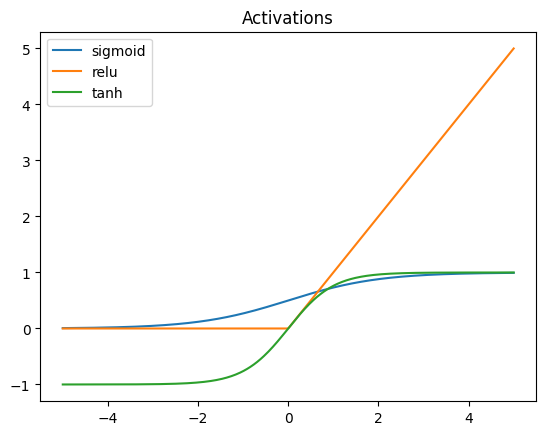

In [2]:
#2 Activation functions & derivatives (visual check)
a = np.linspace(-5,5,400)
def sigmoid(z): return 1/(1+np.exp(-z))
def dsigmoid(z): s=sigmoid(z); return s*(s-1)*-1
def relu(z): return np.maximum(0,z)
def drelu(z): return (z>0).astype(float)
def tanh(z): return np.tanh(z)
def dtanh(z): return 1-np.tanh(z)**2
for f,name in [(sigmoid,'sigmoid'),(relu,'relu'),(tanh,'tanh')]:
    plt.plot(a, f(a), label=name)
plt.legend(); plt.title('Activations'); plt.show()

In [3]:
#3 Manual backprop on XOR (2-2-1 MLP)
np.random.seed(0)
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)  # XOR
y = np.array([[0],[1],[1],[0]], dtype=float)
def init():
    W1=np.random.randn(2,2)*0.5; b1=np.zeros((1,2))
    W2=np.random.randn(2,1)*0.5; b2=np.zeros((1,1))
    return W1,b1,W2,b2
W1,b1,W2,b2 = init(); lr=0.1
def forward(X):
    z1=X@W1+b1; a1=np.tanh(z1)
    z2=a1@W2+b2; a2=1/(1+np.exp(-z2))  # sigmoid
    return z1,a1,z2,a2
for epoch in range(5000):
    z1,a1,z2,a2 = forward(X)
    loss = ((a2-y)**2).mean()
    # backprop
    da2 = 2*(a2-y)/len(X); dz2 = da2*(a2*(1-a2))
    dW2 = a1.T@dz2; db2 = dz2.sum(0, keepdims=True)
    da1 = dz2@W2.T; dz1 = da1*(1-np.tanh(z1)**2)
    dW1 = X.T@dz1; db1 = dz1.sum(0, keepdims=True)
    # update
    W1-=lr*dW1; b1-=lr*db1; W2-=lr*dW2; b2-=lr*db2
    if epoch%500==0: print(epoch, "loss=", round(float(loss),4))
print("Predictions:", (forward(X)[3]>0.5).astype(int).ravel())

0 loss= 0.2455
500 loss= 0.1753
1000 loss= 0.1468
1500 loss= 0.1372
2000 loss= 0.1331
2500 loss= 0.1309
3000 loss= 0.1296
3500 loss= 0.1288
4000 loss= 0.1282
4500 loss= 0.1277
Predictions: [0 0 1 1]
